In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## All data

In [47]:
data_path = '../data/02_intermediate/preprocessed_creep_data.pq'
df = pd.read_parquet(data_path)
df

,Material,Family,Material_info,Dry_or_cond,Manufacturer,Polymer,Fiber_percentage,Fiber_type,Charpy_notched_+23C,Charpy_notched_-30C,...,CM_10,CM_100,CM_1000,CM_10000,CM_100000,R_10/1,R_100/10,R_1000/100,R_10000/1000,R_100000/10000
0,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,769.231,645.161,540.541,434.783,NaN,0.884616,0.838709,0.837839,0.804348,NaN
1,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,701.754,597.015,512.820,430.108,NaN,0.894736,0.850747,0.858973,0.838711,NaN
2,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,618.557,535.714,461.538,392.157,NaN,0.876290,0.866071,0.861538,0.849674,NaN
3,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,571.429,484.848,418.848,353.982,NaN,0.871429,0.848483,0.863875,0.845132,NaN
4,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,511.524,429.765,369.232,312.232,NaN,0.847924,0.840166,0.859149,0.845626,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6356,Zytel® XT70G35HSL BK044A,Zytel®,XT70G35HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.35,GF,13.0,NaN,...,1973.680,1734.100,1470.590,NaN,NaN,0.868418,0.878613,0.848042,NaN,NaN
6357,Zytel® XT70G50HSL BK044A,Zytel®,XT70G50HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.50,GF,15.0,13.0,...,6512.300,6480.650,6101.690,NaN,NaN,0.990262,0.995140,0.941524,NaN,NaN
6358,Zytel® XT70G50HSL BK044A,Zytel®,XT70G50HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.50,GF,15.0,13.0,...,5836.580,5769.230,5454.550,NaN,NaN,0.992219,0.988461,0.945455,NaN,NaN
6359,Zytel® XT70G50HSL BK044A,Zytel®,XT70G50HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.50,GF,15.0,13.0,...,5154.640,5060.890,4804.800,NaN,NaN,0.994791,0.981813,0.949398,NaN,NaN


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Material                               6361 non-null   object 
 1   Family                                 6361 non-null   object 
 2   Material_info                          6361 non-null   object 
 3   Dry_or_cond                            6361 non-null   object 
 4   Manufacturer                           6361 non-null   object 
 5   Polymer                                6361 non-null   object 
 6   Fiber_percentage                       6361 non-null   float64
 7   Fiber_type                             6361 non-null   object 
 8   Charpy_notched_+23C                    4196 non-null   float64
 9   Charpy_notched_-30C                    4079 non-null   float64
 10  Charpy_+23C                            4152 non-null   float64
 11  Tens

In [49]:
df.describe()

,Fiber_percentage,Charpy_notched_+23C,Charpy_notched_-30C,Charpy_+23C,Tensile_modulus,Molding_shrinkage_normal,Molding_shrinkage_parallel,Coeff_linear_therm_expansion_normal,Coeff_linear_therm_expansion_parallel,Melting_temp,...,CM_10,CM_100,CM_1000,CM_10000,CM_100000,R_10/1,R_100/10,R_1000/100,R_10000/1000,R_100000/10000
count,6361.000000,4196.000000,4079.000000,4152.000000,6225.000000,5089.000000,5089.000000,4730.000000,5963.000000,4559.000000,...,6354.000000,6357.000000,6327.000000,4705.000000,2352.000000,4669.000000,6350.000000,6327.000000,4705.000000,2352.000000
mean,0.174881,21.975906,14.505271,72.922086,6417.309237,0.976773,0.662822,89.931501,57.984018,233.629085,...,3049.350021,2775.954180,2476.538926,1843.517995,1537.210701,0.901482,0.887109,0.869638,0.846278,0.826634
std,0.185847,25.180744,21.220688,60.941494,5035.841801,0.378416,0.493517,34.065030,43.165808,35.884871,...,3093.857653,2885.287474,2616.534016,2117.047809,1460.180376,0.058745,0.074643,0.088913,0.103952,0.131294
min,0.000000,2.000000,2.000000,1.500000,12.000000,0.300000,0.100000,24.000000,4.000000,134.000000,...,8.649330,8.161390,7.725250,7.281490,6.097560,0.598983,0.413901,0.360545,0.348859,0.324044
25%,0.000000,7.000000,6.500000,35.000000,2400.000000,0.700000,0.300000,65.000000,22.000000,220.000000,...,1083.590000,865.216000,677.584000,471.698000,471.715250,0.876290,0.866401,0.843090,0.813042,0.817746
50%,0.150000,12.000000,10.000000,65.000000,4500.000000,0.900000,0.500000,85.000000,50.000000,223.000000,...,2043.020000,1873.580000,1679.560000,1150.570000,1109.265000,0.915640,0.907551,0.895161,0.875283,0.871192
75%,0.300000,18.000000,14.000000,90.000000,9800.000000,1.100000,0.700000,105.000000,85.000000,260.000000,...,4050.540000,3727.250000,3404.000000,2504.070000,2126.467500,0.941544,0.936364,0.928521,0.915563,0.914667
max,0.650000,120.000000,160.000000,300.000000,22500.000000,2.100000,2.400000,230.000000,230.000000,340.000000,...,24861.300000,24468.600000,23190.700000,20970.200000,12576.400000,0.999463,0.999415,0.999612,0.996404,0.987717


## Numeric data

In [50]:
df_num = df.select_dtypes(include=np.number)

In [53]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Fiber_percentage                       6361 non-null   float64
 1   Charpy_notched_+23C                    4196 non-null   float64
 2   Charpy_notched_-30C                    4079 non-null   float64
 3   Charpy_+23C                            4152 non-null   float64
 4   Tensile_modulus                        6225 non-null   float64
 5   Molding_shrinkage_normal               5089 non-null   float64
 6   Molding_shrinkage_parallel             5089 non-null   float64
 7   Coeff_linear_therm_expansion_normal    4730 non-null   float64
 8   Coeff_linear_therm_expansion_parallel  5963 non-null   float64
 9   Melting_temp                           4559 non-null   float64
 10  Temp_deflection_0.45MPa                5562 non-null   float64
 11  Temp

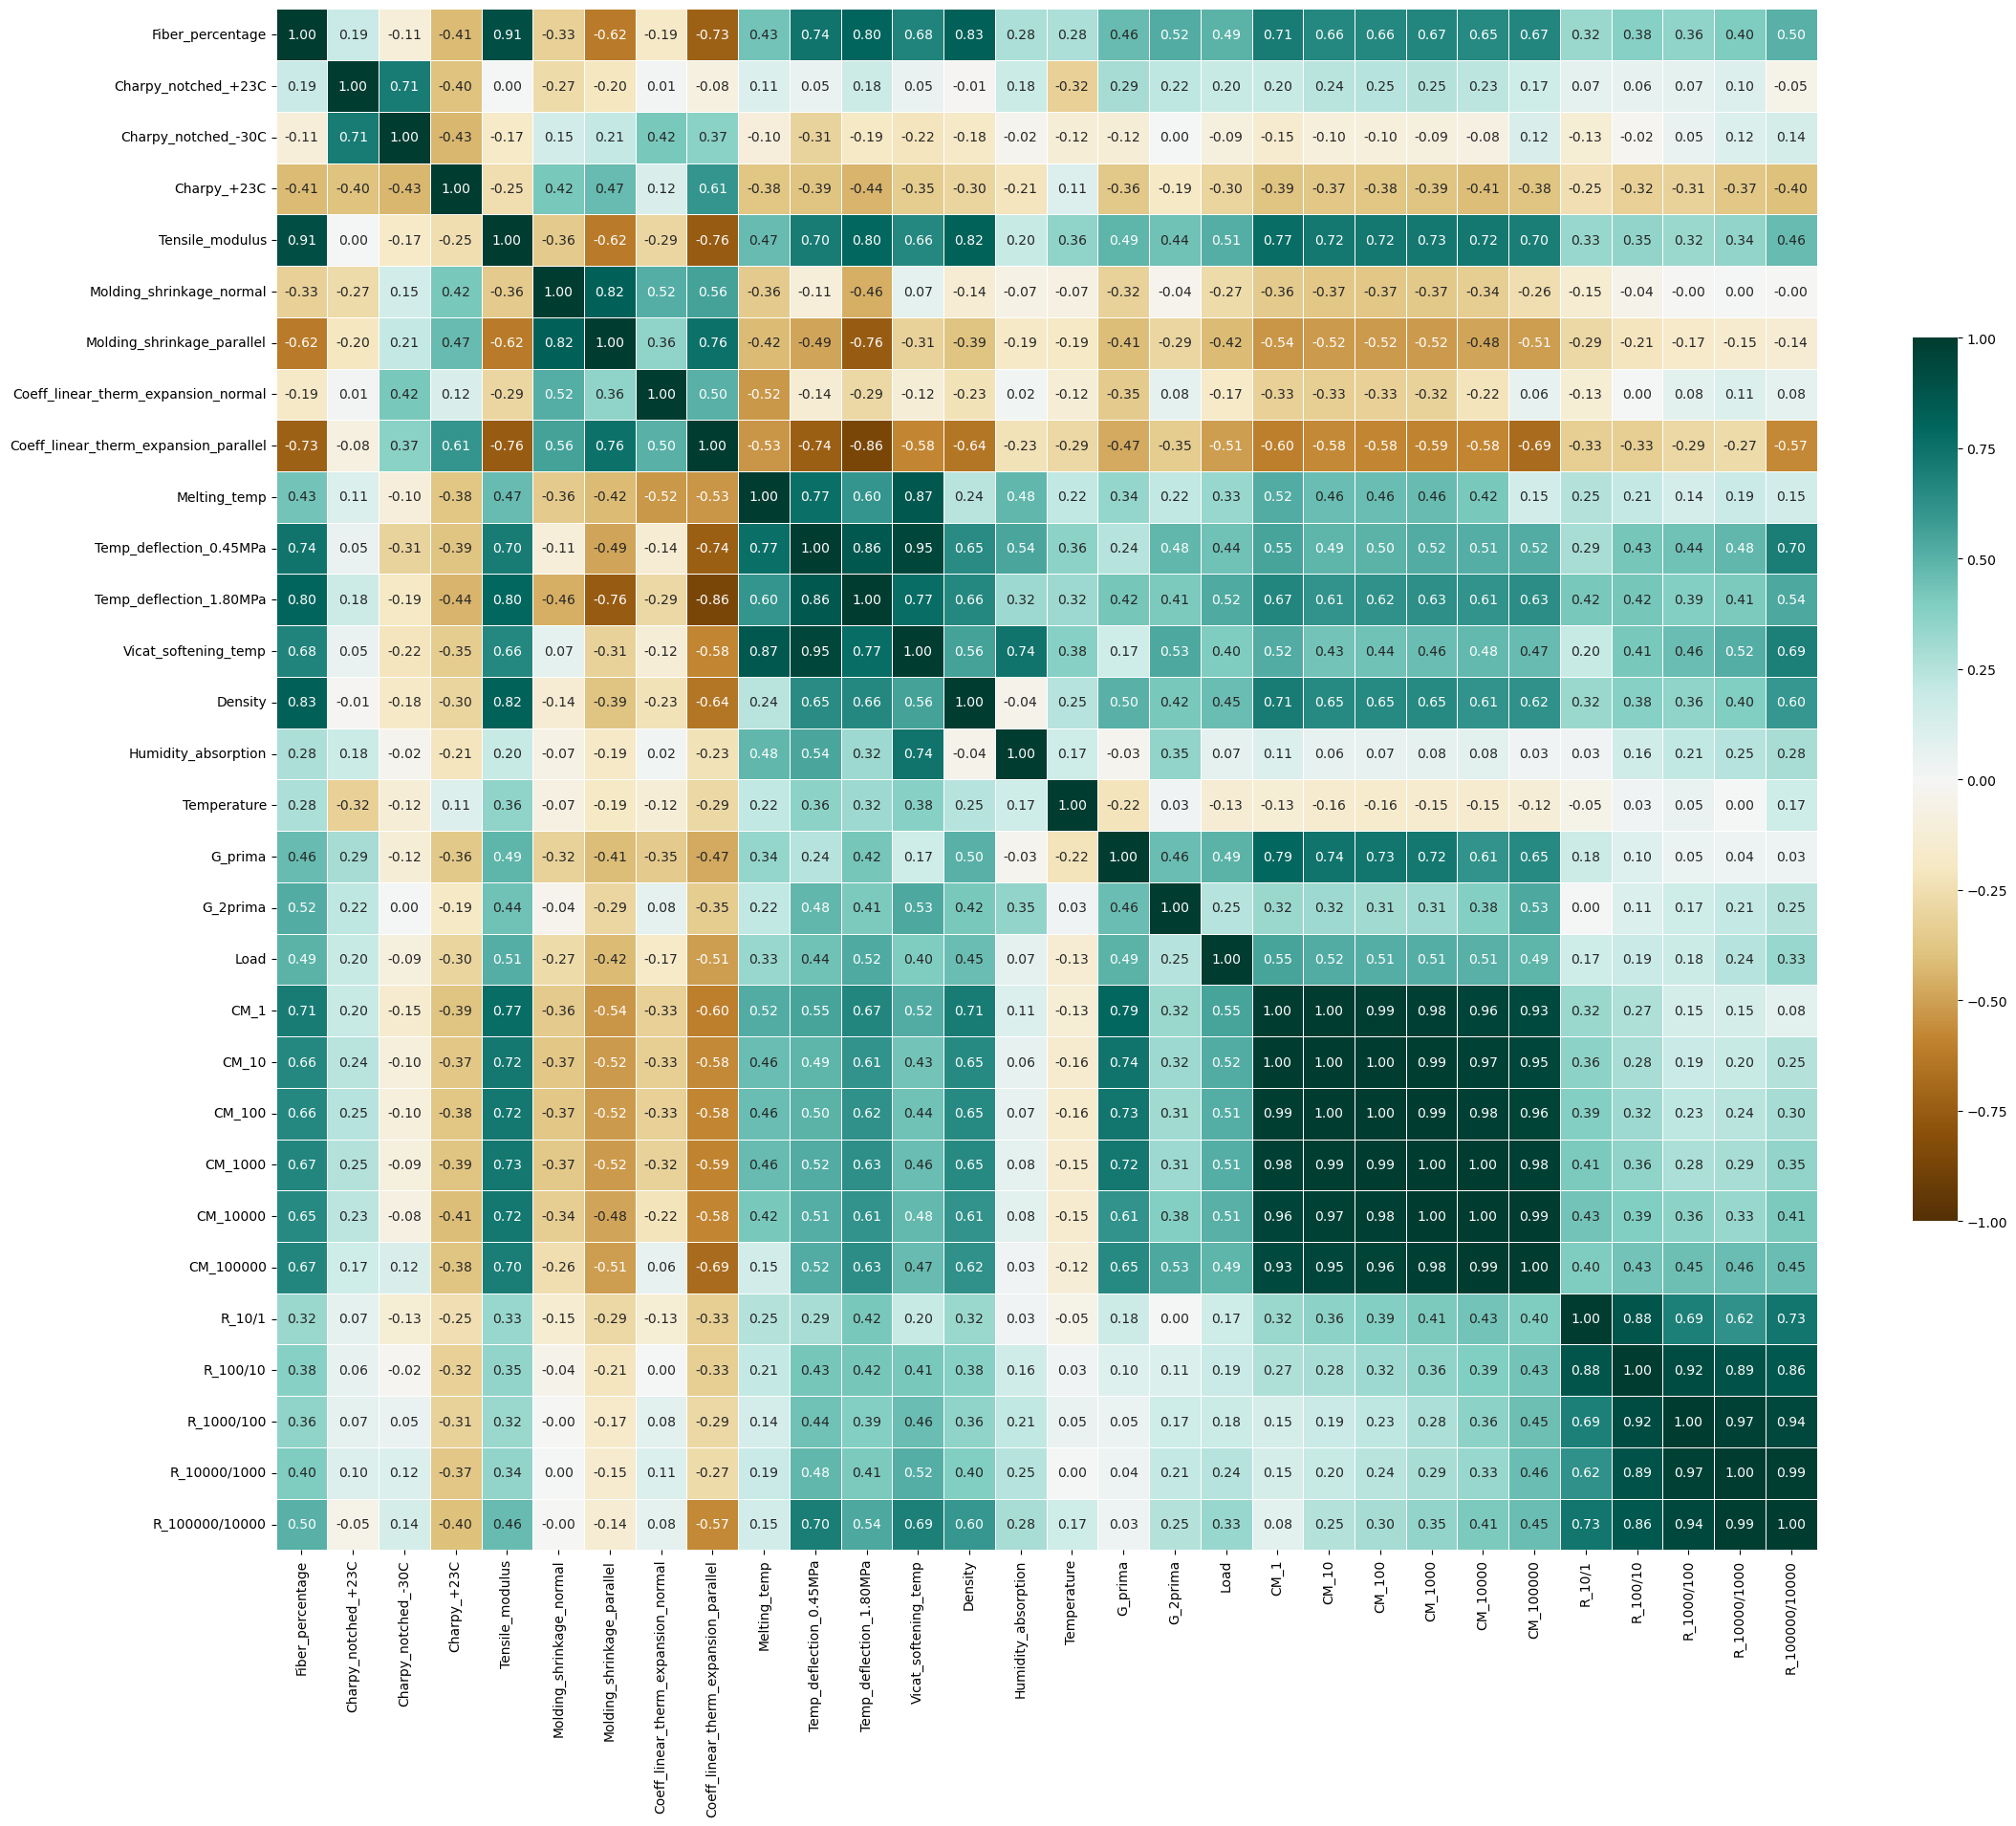

In [52]:
fig, ax = plt.subplots(figsize=(26,24))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='BrBG', vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={'shrink':.5})
plt.show()

## Counting

In [7]:
len(df.Material.unique())

415

In [8]:
len(df.Family.unique())

44

In [9]:
df.Family.value_counts()

Ultramid®       1213
Makrolon®        950
Ultradur®        583
Zytel®           468
Luran®           304
Durethan         296
Ultraform®       249
Crastin®         203
Grivory          189
Hytrel®          187
Akulon®          165
Grilon           159
Pocan            144
Stanyl®          137
Apec®             93
Ultrason®         91
VESTAMID®         75
PLEXIGLAS®        71
CELANEX®          66
HOSTAFORM®        64
Rilsan®           63
Pebax®            62
FORTRON®          53
Elastollan®       52
Grilamid          43
Minlon®           40
Novodur®          36
Styrolution®      33
Styrolux®         27
Terluran®         23
Terblend®         23
Rilsamid®         23
Arnite®           22
Bayblend®         21
IMPET®            20
Terlux®           19
VESTODUR®         18
Orgalloy®         18
Delrin®           16
CELCON®           14
Rynite®           12
TROGAMID®          9
CELSTRAN®          4
VESTAKEEP®         3
Name: Family, dtype: int64

In [10]:
len(df.Polymer.unique())

49

In [11]:
df.Polymer.value_counts()

PA66                               1138
PC                                 1043
PA6                                 924
PBT                                 810
POM                                 292
TPC                                 187
ASA                                 166
PA46                                137
PA666                               113
PA12                                101
SAN                                  97
PBT+ASA+PET                          87
PA66+PA6I/X                          83
PA6T/6                               78
TPA                                  73
PMMA                                 71
PA6T/6I                              70
PBT+PET                              65
PA11                                 63
PESU                                 60
ABS                                  59
PPS                                  53
TPU                                  52
POM+PUR                              51
PET                                  47


In [12]:
len(df.Fiber_type.unique())

10

In [13]:
df.Fiber_type.value_counts()

None     2983
GF       2979
M          97
GF+M       94
GB         87
GF+GB      39
GF+MF      37
CF         24
GLF        16
P+GF        5
Name: Fiber_type, dtype: int64

In [14]:
len(df.Temperature.unique())

14

In [15]:
df.Temperature.value_counts()

23.0     2345
60.0      780
120.0     730
90.0      674
40.0      638
80.0      364
140.0     212
160.0     189
100.0     182
150.0      98
180.0      65
200.0      38
110.0      26
130.0      20
Name: Temperature, dtype: int64

In [16]:
len(df.Load.unique())

82

In [17]:
df.Load.value_counts()

10.0    900
20.0    771
30.0    530
5.0     513
15.0    490
       ... 
49.0      1
54.0      1
87.0      1
59.0      1
29.0      1
Name: Load, Length: 82, dtype: int64

## Histograms:

In [18]:
def plot_histograms(df_list, label_list=None, n_bins=10, n_cols=6):
    '''Make subplots for histograms of each feature in each df in df_list. Maximum 6 subplots per row.
    Each df in df_list will have its own color'''

    df_ = pd.DataFrame(df_list[0]) # Get first df in df_list for formatting. Supposing all dfs in df_list have the same columns. 
    # Converted to DataFrame to allow for column names in case it is a series

    n_rows = int(np.ceil(len(df_.columns) / 6))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), tight_layout=True)

    #Make color list for each df in df_list from 'tab10' color palette
    colors = sns.color_palette('tab10', len(df_list))

    for j, df in enumerate(df_list):
        if isinstance(df, pd.Series): #If df is a series, convert to dataframe
            df = df.to_frame()
        for i, col in enumerate(df.columns):
            ax = axes.flatten()[i]
            ax.hist(df[col], bins=n_bins, color=colors[j], alpha=0.5)
            ax.set_title(col)
        if label_list:
            #locate legend outside of subplots, in the top center, with bigger font
            fig.legend(label_list, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(df_list), fontsize='x-large')

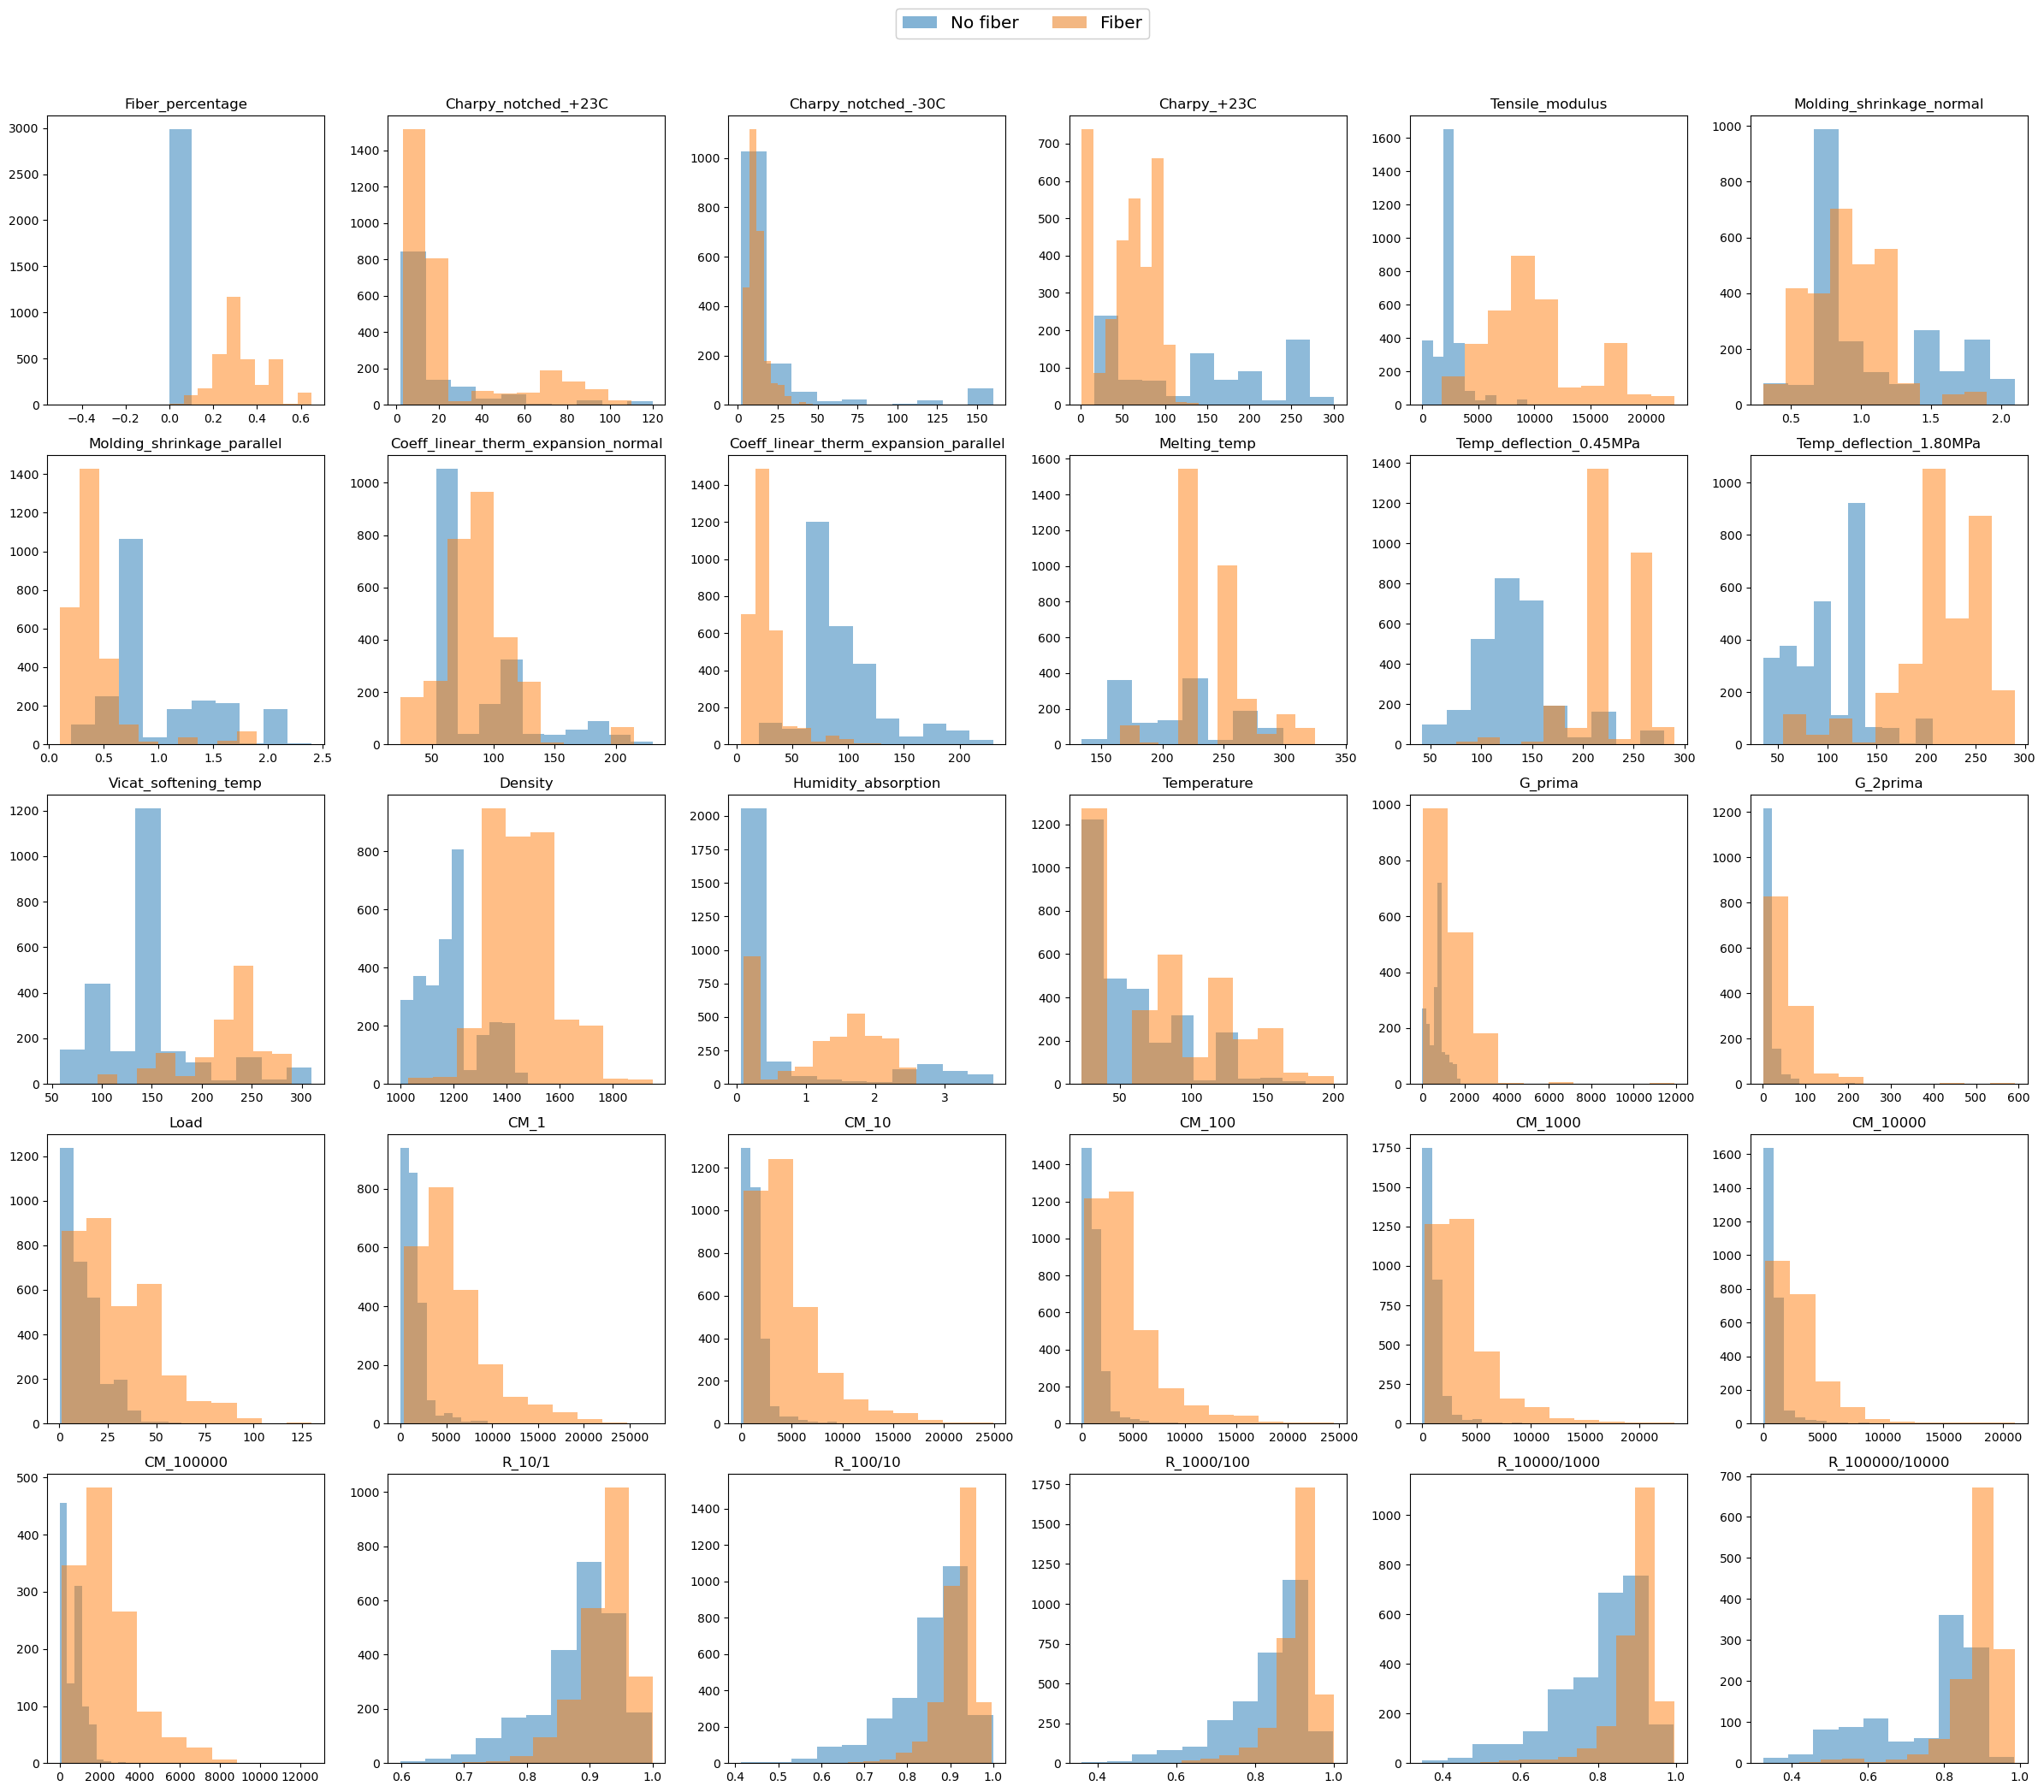

In [19]:
df_no_fiber = df[df['Fiber_type'] == 'None'].select_dtypes(include=np.number)
df_fiber = df[df['Fiber_type'] != 'None'].select_dtypes(include=np.number)

plot_histograms([df_no_fiber, df_fiber], label_list=['No fiber', 'Fiber'])

## Model data

In [20]:
model_df = pd.read_parquet('../data/02_intermediate/model_data.pq')
model_df

,Temperature,R_1000/100,R_100/10,Load,Family,R_10000/1000
0,23.0,0.837839,0.838709,2.0,Akulon®,0.804348
1,23.0,0.858973,0.850747,4.0,Akulon®,0.838711
2,23.0,0.861538,0.866071,6.0,Akulon®,0.849674
3,23.0,0.863875,0.848483,8.0,Akulon®,0.845132
4,23.0,0.859149,0.840166,10.0,Akulon®,0.845626
...,...,...,...,...,...,...
6346,23.0,0.828572,0.849137,2.0,Zytel®,0.818713
6347,23.0,0.821312,0.838323,4.0,Zytel®,0.794270
6348,23.0,0.816831,0.829091,6.0,Zytel®,0.765151
6349,23.0,0.800000,0.822580,8.0,Zytel®,0.756098


In [21]:
info = pd.read_parquet('../data/02_intermediate/info_data.pq')
info

,Material,Family,Material_info,Dry_or_cond,Manufacturer,Polymer,Fiber_type,Temperature,Load,R_10/1,R_100/10,R_1000/100,R_10000/1000,R_100000/10000,CM_1,CM_10,CM_100,CM_1000,CM_10000,CM_100000
0,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,None,23.0,2.0,0.884616,0.838709,0.837839,0.804348,NaN,869.565,769.231,645.161,540.541,434.783,NaN
1,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,None,23.0,4.0,0.894736,0.850747,0.858973,0.838711,NaN,784.314,701.754,597.015,512.820,430.108,NaN
2,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,None,23.0,6.0,0.876290,0.866071,0.861538,0.849674,NaN,705.882,618.557,535.714,461.538,392.157,NaN
3,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,None,23.0,8.0,0.871429,0.848483,0.863875,0.845132,NaN,655.738,571.429,484.848,418.848,353.982,NaN
4,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,None,23.0,10.0,0.847924,0.840166,0.859149,0.845626,NaN,603.266,511.524,429.765,369.232,312.232,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6346,Zytel® ST801 NC010A,Zytel®,ST801 NC010A,cond,DuPont Engineering Polymers,PA66,None,23.0,2.0,NaN,0.849137,0.828572,0.818713,NaN,NaN,1015.230,862.069,714.286,584.795,NaN
6347,Zytel® ST801 NC010A,Zytel®,ST801 NC010A,cond,DuPont Engineering Polymers,PA66,None,23.0,4.0,NaN,0.838323,0.821312,0.794270,NaN,NaN,952.381,798.403,655.738,520.833,NaN
6348,Zytel® ST801 NC010A,Zytel®,ST801 NC010A,cond,DuPont Engineering Polymers,PA66,None,23.0,6.0,NaN,0.829091,0.816831,0.765151,NaN,NaN,877.193,727.273,594.059,454.545,NaN
6349,Zytel® ST801 NC010A,Zytel®,ST801 NC010A,cond,DuPont Engineering Polymers,PA66,None,23.0,8.0,NaN,0.822580,0.800000,0.756098,NaN,NaN,784.314,645.161,516.129,390.244,NaN


## Target: PA6 with Glass Fiber

In [22]:
df_ = model_df.copy()
print(f'Number of samples: {len(df_)}')

PA_rows = info.loc[info.Polymer.str.contains('PA6'), :].index.to_list()
print(f'Number of PA6 samples: {len(PA_rows)}')

GF_rows = info.loc[info.Fiber_type == 'GF', :].index.to_list()
print(f'Number of GF samples: {len(GF_rows)}')

ultramid_rows = info.loc[info.Family == 'Ultramid®', :].index.to_list()
print(f'Number of Ultramid samples: {len(ultramid_rows)}')

#df_target = df_.loc[(df_.index.isin(PA_rows)) & (df_.index.isin(GF_rows)) & (~df_.index.isin(ultramid_rows)), :]
df_target = df_.loc[(df_.index.isin(PA_rows)) & (df_.index.isin(GF_rows)), :]
df_others = df_.loc[~df_.index.isin(df_target.index)]

print(f'Number of target samples: {len(df_target)}')

Number of samples: 4705
Number of PA6 samples: 1592
Number of GF samples: 1828
Number of Ultramid samples: 1203
Number of target samples: 1131


In [23]:
df_target.Family.value_counts()

Ultramid®    907
Zytel®       136
Grilon        46
Grivory       24
Terblend®     12
Orgalloy®      6
Name: Family, dtype: int64

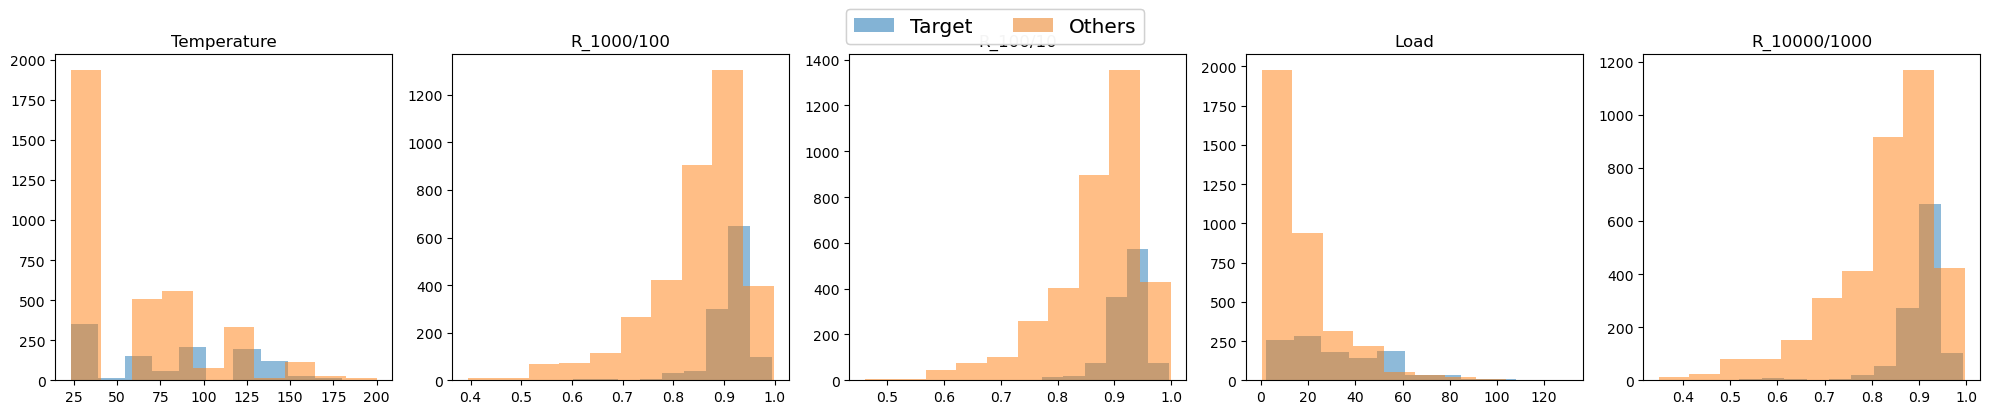

In [24]:
plot_histograms([df_target.select_dtypes(include=np.number), df_others.select_dtypes(include=np.number)], 
                label_list=['Target', 'Others'], n_cols=5)

In [25]:
def df_clustering(df, n_clusters=3):
    """Function to cluster dataframe into n_clusters by means of unsupervised learning.
    First, features in df are standardized. Then, KMeans is used to cluster the data.
    Finally, cluster number column is appended to original df.
    """
    df_ = df.copy()
    df_ = df_.apply(lambda x: (x - x.mean()) / x.std()) #Standardize features
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(df_)

    df_2 = df.copy()
    df_2['cluster'] = kmeans.labels_

    return df_2

In [26]:
def plot_clusters(df_clustered, plot_column_numbers=[0, 1, 2]):
    '''Function to plot clusters in a dataframe into a 3D plot'''
    from matplotlib import cm
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')

    X = df_clustered.copy()

    labels = X['cluster']

    # Plot the clusters and add labels for each cluster
    ax.scatter(X.iloc[:, plot_column_numbers[0]], 
               X.iloc[:, plot_column_numbers[1]], 
               X.iloc[:, plot_column_numbers[2]], c=labels, cmap=cm.gist_rainbow)

    ax.set_xlabel(df_clustered.columns[plot_column_numbers[0]])
    ax.set_ylabel(df_clustered.columns[plot_column_numbers[1]])
    ax.set_zlabel(df_clustered.columns[plot_column_numbers[2]])
    ax.set_title('Clusters')
    plt.show()

In [29]:
df_ultramid = df.loc[df.Family == 'Ultramid®', :]

In [30]:
df_ultramid

,Material,Family,Material_info,Dry_or_cond,Manufacturer,Polymer,Fiber_percentage,Fiber_type,Charpy_notched_+23C,Charpy_notched_-30C,...,CM_10,CM_100,CM_1000,CM_10000,CM_100000,R_10/1,R_100/10,R_1000/100,R_10000/1000,R_100000/10000
4493,Ultramid® A3EG10,Ultramid®,A3EG10,cond,BASF,PA66,0.50,GF,NaN,25.0,...,11065.70,10386.60,9543.50,8544.97,7426.51,NaN,0.938630,0.918828,0.895371,0.869109
4494,Ultramid® A3EG10,Ultramid®,A3EG10,cond,BASF,PA66,0.50,GF,NaN,25.0,...,9532.80,8654.23,7677.35,6642.30,5599.94,NaN,0.907837,0.887121,0.865181,0.843072
4495,Ultramid® A3EG10,Ultramid®,A3EG10,cond,BASF,PA66,0.50,GF,NaN,25.0,...,8391.72,7526.67,6622.68,5713.94,4835.36,NaN,0.896916,0.879895,0.862784,0.846239
4496,Ultramid® A3EG10,Ultramid®,A3EG10,cond,BASF,PA66,0.50,GF,NaN,25.0,...,7528.91,6760.30,5984.32,5222.91,4496.32,NaN,0.897912,0.885215,0.872766,0.860884
4497,Ultramid® A3EG10,Ultramid®,A3EG10,cond,BASF,PA66,0.50,GF,NaN,25.0,...,7174.17,6467.38,5761.36,5072.59,4415.94,NaN,0.901481,0.890834,0.880450,0.870549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5701,Ultramid® T KR 4365 G5,Ultramid®,T KR 4365 G5,dry,BASF,PA6T/6,0.25,GF,8.0,NaN,...,2343.97,2189.39,1940.57,1589.42,1174.99,NaN,0.934052,0.886352,0.819048,0.739257
5702,Ultramid® T KR 4365 G5,Ultramid®,T KR 4365 G5,dry,BASF,PA6T/6,0.25,GF,8.0,NaN,...,2287.81,2138.58,1921.60,1635.59,1300.73,NaN,0.934772,0.898540,0.851160,0.795267
5703,Ultramid® T KR 4365 G5,Ultramid®,T KR 4365 G5,dry,BASF,PA6T/6,0.25,GF,8.0,NaN,...,2140.31,1980.42,1778.24,1538.70,1276.68,NaN,0.925296,0.897911,0.865294,0.829713
5704,Ultramid® T KR 4365 G5,Ultramid®,T KR 4365 G5,dry,BASF,PA6T/6,0.25,GF,8.0,NaN,...,1891.07,1740.04,1571.34,1390.34,1203.88,NaN,0.920135,0.903048,0.884812,0.865889
